# Titanic Survival Prediction

This notebook documents an end-to-end machine learning workflow on the Kaggle Titanic dataset.

**Workflow**
- Data Loading
- Exploratory Data Analysis
- Data Cleaning
- Feature Engineering
- Encoding
- Model Training
- Hyperparameter Tuning
- Feature Importance
- Kaggle Submission


In [1]:
import sys
print(sys.executable)

/home/ojaswi/Projects/titanic_proj/.venv/bin/python


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("necessary imports")

necessary imports


In [3]:
# loading the training and testing databases

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

In [4]:
# checking whether data is properly loaded
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
import seaborn as sns

In [6]:
# going through the structure of the training dataset

train.shape
train.columns
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# numerical columns - PassengerId, Survived, Age, SibSp, Parch, Fare
# categorical columns - Pclass(1, 2, 3), Embarked (S = Southampton, C = Cherbourg, Q = Queenston), Sex (male, female)
# object columns - Name, Ticket, Cabin

<Axes: xlabel='Age', ylabel='Count'>

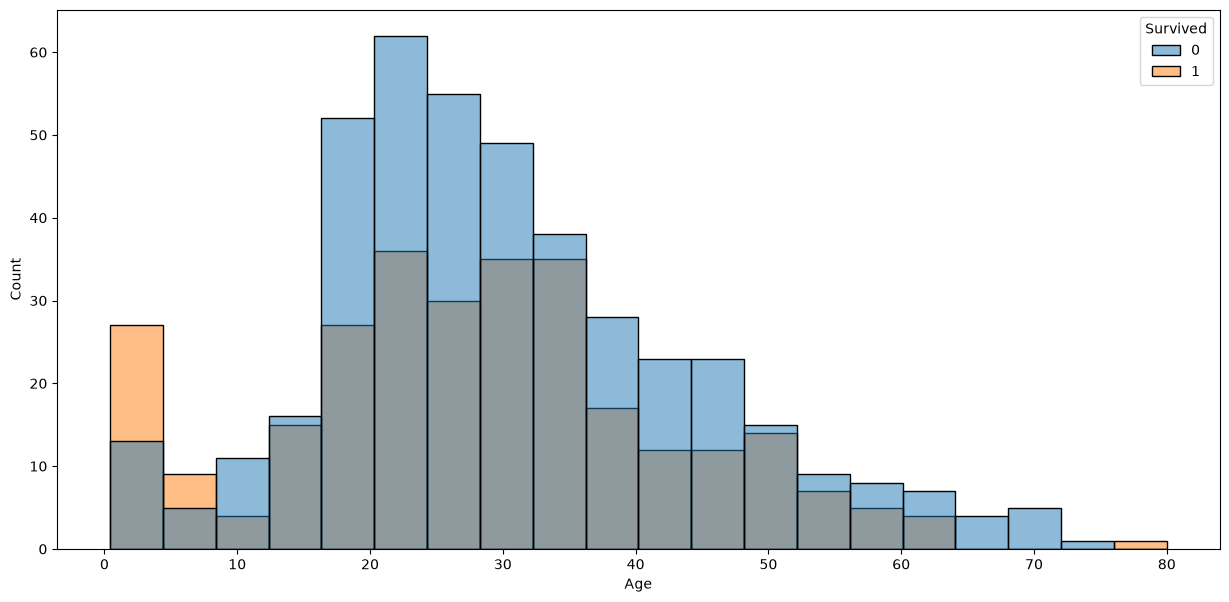

In [8]:
# histogram for survivers 
plt.figure(figsize = (15, 7))
sns.histplot(data = train, x = "Age", hue = "Survived")

<Axes: xlabel='Age', ylabel='Density'>

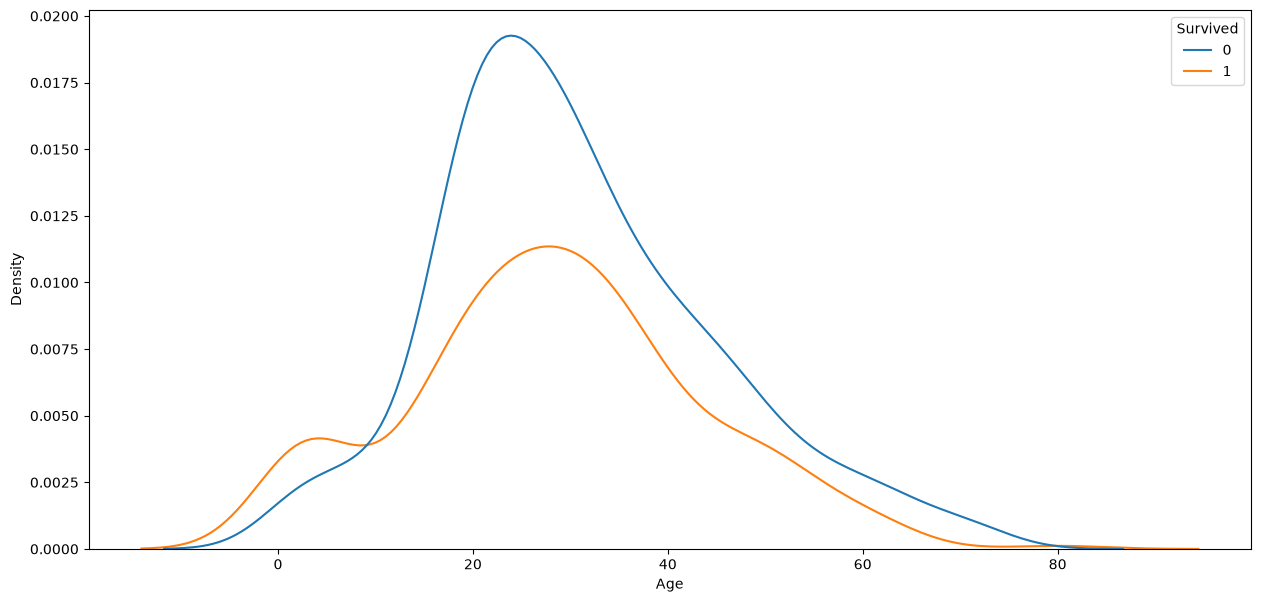

In [9]:
# kde plot for the same
plt.figure(figsize = (15, 7))
sns.kdeplot(data = train, x = "Age", hue = "Survived")

<Axes: xlabel='Age', ylabel='Count'>

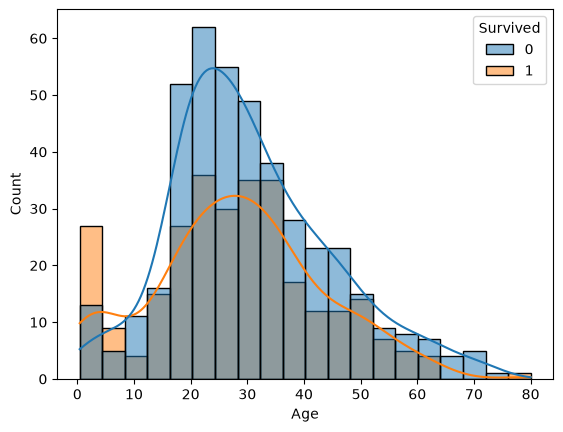

In [10]:
# apparantly to achieve what i want right now, I'll have to use histplot, but with an attribute - kde
sns.histplot(data = train, x = "Age", kde = True, stat = "count", hue = "Survived")
# perfect

In [11]:
# so basically the highest rate of survival was seen among people aged around 30, and least for those above 70

<Axes: xlabel='Pclass', ylabel='Survived'>

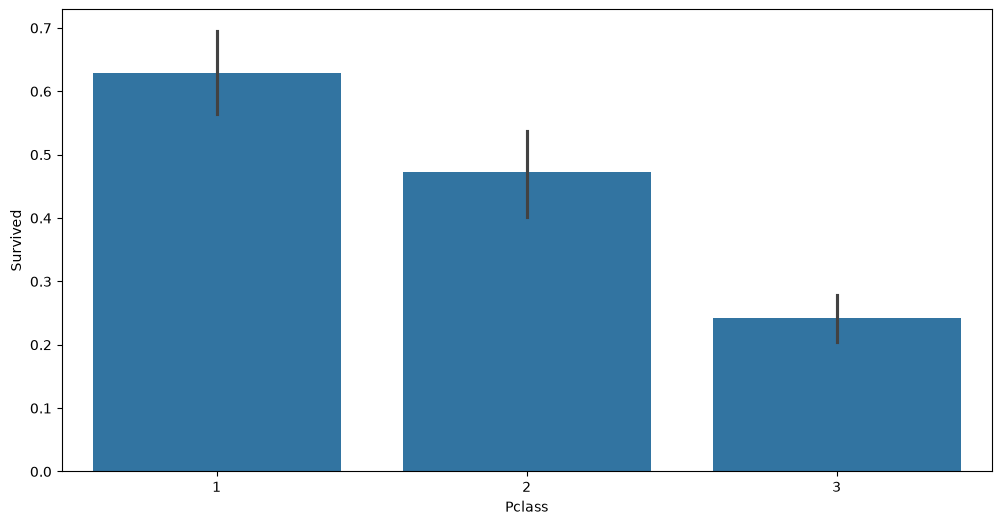

In [12]:
# question 2 - does class affect survival?
plt.figure(figsize = (12, 6))
sns.barplot(data = train, x = train["Pclass"], y = train["Survived"])

In [13]:
# class does affect the survival, the 3rd class (lowest) has the lowest rate of survival

<Axes: xlabel='Survived', ylabel='count'>

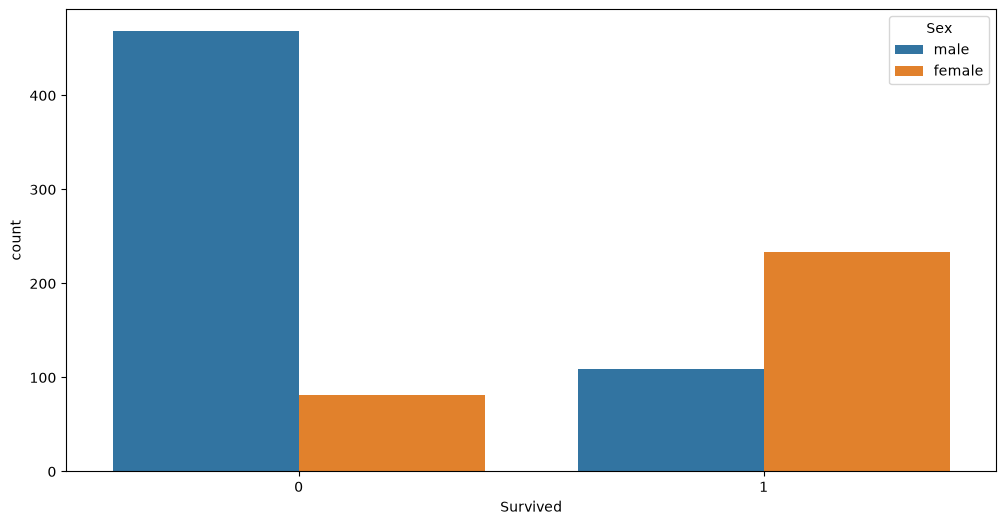

In [14]:
# question 3 - does gender affect survival?
plt.figure(figsize = (12, 6))
sns.countplot(data = train, x = train["Survived"], hue = train["Sex"])

In [15]:
# used countplot for frequencies rather than ratios
# plot is evident that casualties in males were much larger in number than females

<Axes: xlabel='None', ylabel='count'>

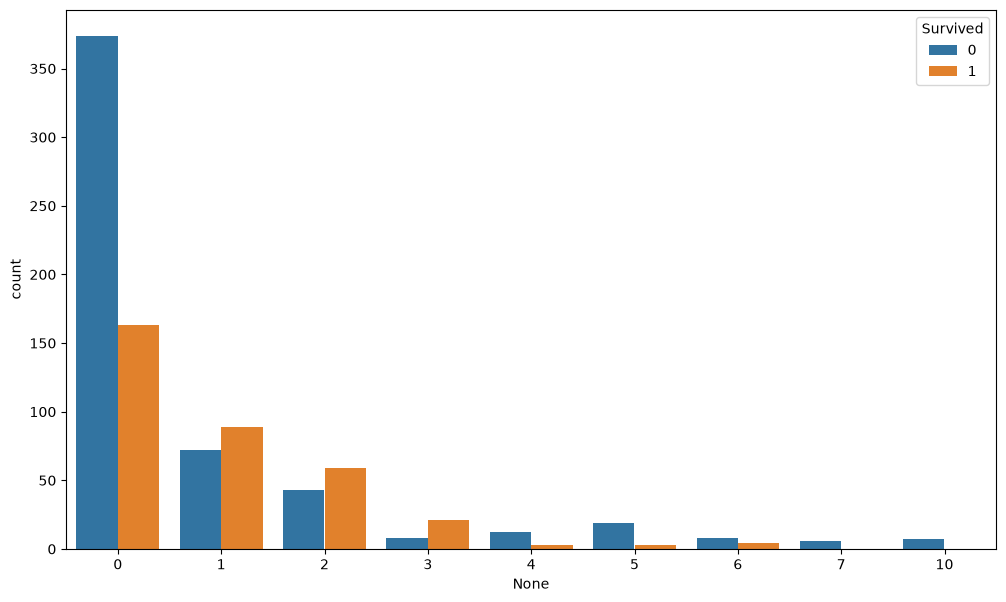

In [16]:
# question 4 - does travelling with family matter? 
plt.figure(figsize = (12, 7))
family_size = train['SibSp'] + train['Parch']
sns.countplot(data = train, x = family_size, hue = train['Survived'])

In [17]:
# used SibSp + Parch as the family size, through the count plot its evident that, although most deaths were 
# among the people with no family members aboard, maximum survival rate was also under the same category
# maximum family size aboard was 10, and maximum-sized family aboard which survived was of 6 members

<Axes: xlabel='Embarked', ylabel='count'>

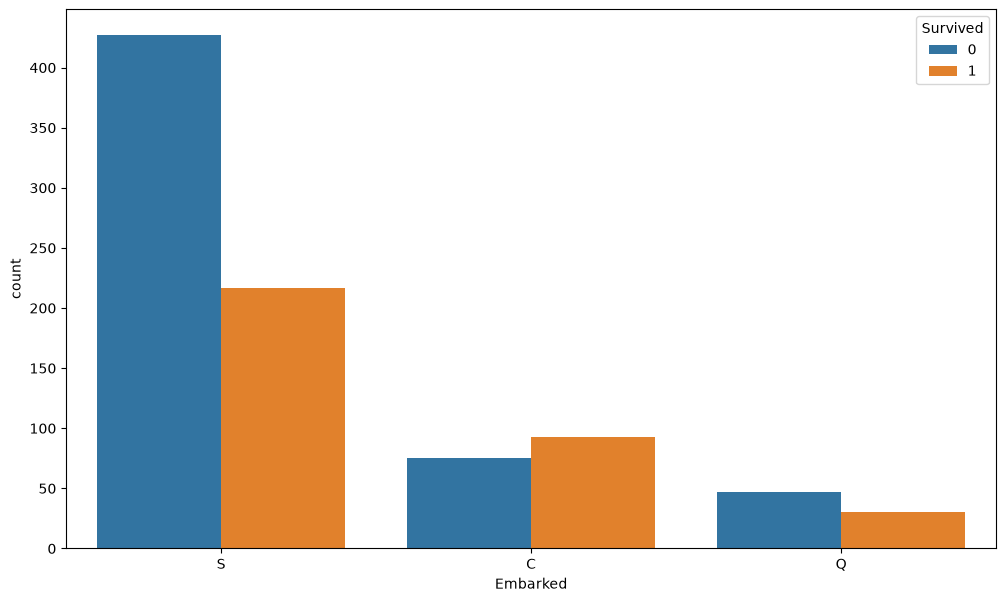

In [18]:
# question 5 - does embarkation port matter?
plt.figure(figsize = (12, 7))
sns.countplot(data = train, x = train["Embarked"], hue = train["Survived"])

In [19]:
# there is a considerable difference in number of passengers surviving and also number of passengers boarded
# between the 3 different ports, the largest stats are of Southampton
# but, larger survivals from the S section can be largely due to the large amount of boardings from the port, 
# rather than being any other port-specific circumstances
# in my opinion, the embarkment port doesn't hold much of an importance for this analysis

Text(0.5, 0, 'Embarkment Port')

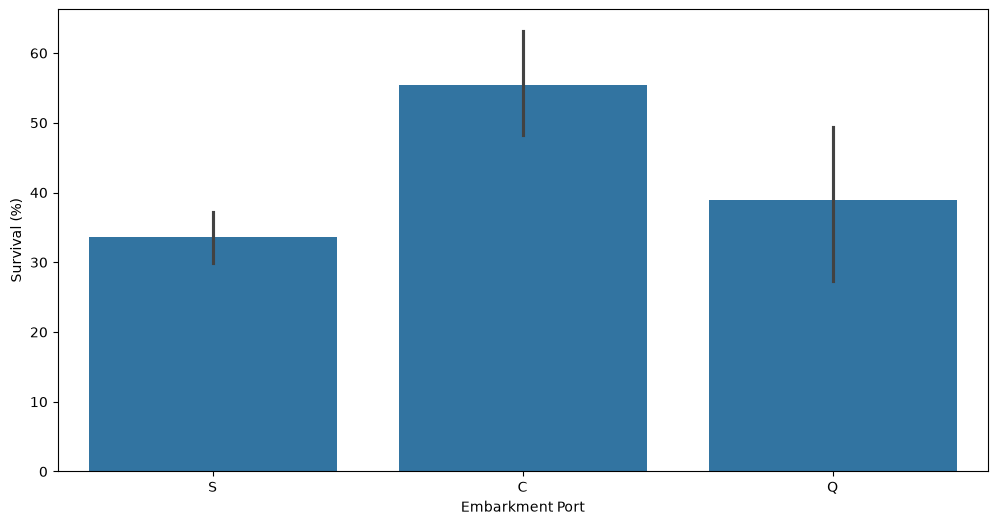

In [20]:
# to verify, I'll get a barplot for 'Embarked' vs 'Survived'
# if what i think is correct, I should see that the proportion of survival is very less for Southampton port
# despite having the highest number, whereas, proportion for the same from Cherbourg is highest as
# a large number of class 1 passengers boarded from Cherbourg, whereas, the from Southampton,
# high number of 3rd class passengers boarded
plt.figure(figsize = (12,6))
sns.barplot(x = train["Embarked"], y = train["Survived"]*100, data = train)  # *100 for percentage
plt.ylabel("Survival (%)")
plt.xlabel("Embarkment Port")

In [21]:
# analysing missing data
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [22]:
# 177 age values missing, not so bad but can cause problems, but, we won't just delete 177 passengers
# so we can instead fill them up, using the median value of ages
# median instead of mean because, very high or very low values of age can highly impact mean, but not median

In [23]:
# 687 cabin values missing
# probably because the large number of 3rd class passengers were not even given a 'cabin', hence values missing
# by a huge margin, hence we should probably drop this category

In [24]:
# 2 'embarked' values missing, we can assume they also must've boarded from the most common embarkment port
# which according to our analysis was - Southhampton or S
# we'll not hard code, but rather use the first mode value - highest frequency

In [25]:
# filling up age values
train["Age"] = train["Age"].fillna(train["Age"].median())
test["Age"] = test["Age"].fillna(test["Age"].median())
# dropping cabin
train = train.drop(columns = "Cabin")
test = test.drop(columns = "Cabin")
# filling embarked values
train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])
test["Embarked"] = test["Embarked"].fillna(test["Embarked"].mode()[0])

In [26]:
# question 6 - does fare affect survival?
# last EDA question we need to ask from the data

<Axes: xlabel='Survived', ylabel='Fare'>

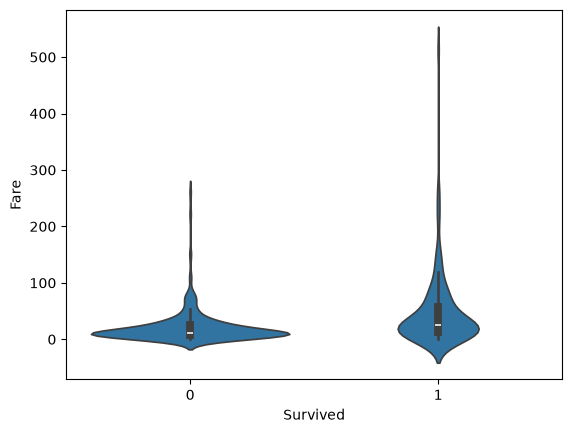

In [27]:
sns.violinplot(data = train, y = train["Fare"], x = train["Survived"])

<Axes: xlabel='Survived', ylabel='Fare'>

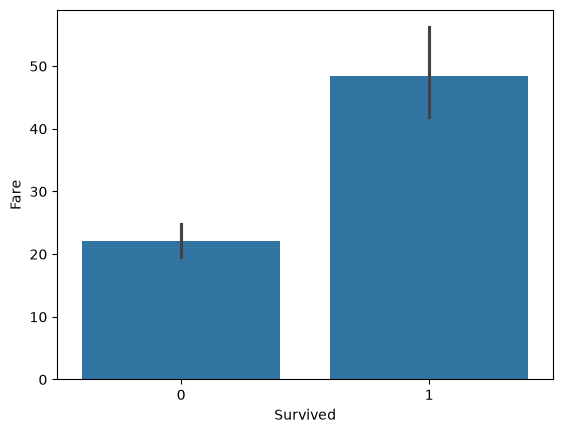

In [28]:
sns.barplot(data = train, x = train["Survived"], y = train["Fare"])

<Axes: xlabel='Fare', ylabel='Count'>

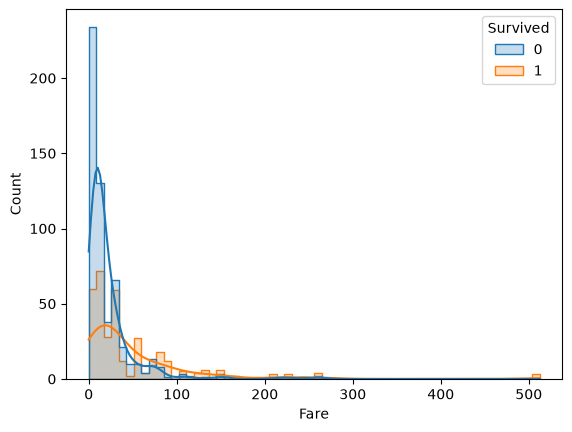

In [29]:
sns.histplot(data = train, x = train["Fare"], hue = train["Survived"], kde = True, element = "step")

In [30]:
# the voilin plot emphasizes on the density and spread of fares
# the bar plot shows the mean fare for the surviving and non-surviving category
# the histplot along with kde showcases specific fare ranges with number of deaths and survivors

In [31]:
# now moving on to feature engineering, adding better and more helpful features to the data
# famsize = 1 + SibSp + Parch
# isalone = 1 if family_size == 1 else 0
# fareperperson = as the name suggests
# title of the passenger - "Mr." or "Mrs." or "Master"

In [32]:
train["famsize"] = train["SibSp"] + train["Parch"] + 1
train["isalone"] = (train["famsize"] > 1).astype(int)
train["fareperperson"] = train["Fare"] / train["famsize"]
# tried this but not correct for many cases - train["title"] = train["Name"].str.split(" ").str[1]
train["title"] = train["Name"].str.extract(r",\s*([^\.]+)\.")
# doing same for test data
test["famsize"] = test["SibSp"] + test["Parch"] + 1
test["isalone"] = (test["famsize"] > 1).astype(int)
test["fareperperson"] = test["Fare"] / test["famsize"]
# test["title"] = test["Name"].str.split(" ").str[1]
test["title"] = test["Name"].str.extract(r",\s*([^\.]+)\.")

In [33]:
train["title"].value_counts()

title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [34]:
train.groupby("title")["Survived"].mean().sort_values()

title
Capt            0.000000
Don             0.000000
Jonkheer        0.000000
Rev             0.000000
Mr              0.156673
Dr              0.428571
Col             0.500000
Major           0.500000
Master          0.575000
Miss            0.697802
Mrs             0.792000
Lady            1.000000
Mme             1.000000
Mlle            1.000000
Ms              1.000000
Sir             1.000000
the Countess    1.000000
Name: Survived, dtype: float64

In [35]:
train["title"] = train["title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
test["title"] = test["title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
# fix- forgot to map for test

In [36]:
train["title"].value_counts()

title
Mr              517
Miss            185
Mrs             126
Master           40
Dr                7
Rev               6
Major             2
Col               2
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [37]:
misc_titles = ["Dr", "Rev","Major", "Col", "Don", "Lady", "Sir", "Capt", "the Countess", "Jonkheer", "Dona"]
# all the titles apart from "Mr", "Mrs", "Miss", "Master" are clubbed into "Rare"
# fix- forgot to account for names which may appear in test, but are not in train, added "Dona"

In [38]:
train["title"] = train["title"].replace(misc_titles, "Rare")
test["title"] = test["title"].replace(misc_titles, "Rare")

In [39]:
train["title"].value_counts()
# perfect now, actually useful attribute to serve as a feature

title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [40]:
# The 'Name' column contains passenger names, which are high-cardinality text values and cannot be directly used by 
# traditional machine learning models. After extracting the title feature, which captures useful information such as 
# gender, age group, and social status, the remaining name text is unlikely to provide enough consistent signal 
# for this dataset. Therefore, the original 'Name' column can be dropped.

In [41]:
test_ids = test["PassengerId"].copy()
# copying PassengerId for Kaggle submission
train = train.drop(columns=["Name", "PassengerId", "Ticket", "SibSp", "Parch"])
test = test.drop(columns=["Name", "PassengerId", "Ticket", "SibSp", "Parch"])

In [42]:
# with this, now we've dropped all the columns we won't be using for the model training, only important 
# parameters remain in the dataset, now
# Moving on with One-Hot Encoding for categorical data

In [43]:
encode_cols = ["Sex", "title", "Embarked"]
train = pd.get_dummies(train, columns = encode_cols, dtype = int)
test = pd.get_dummies(test, columns = encode_cols, dtype = int)

In [44]:
# i left the 'Pclass' variable out from One-hot because, when a variable is one-hot encoded, it loses it's relationship among
# categories, so , classes, 1, 2, and 3 would be viewed like A, B and C, but since, they already have an inherent order of hierarchy
# i would want it to be preserved, and leave it for the model to train on
# tree based models(which I'm gonna use) work fine without proper encoding anyways, logical regression etc. kinda models pose problems
# will look in to that later

In [45]:
train.columns

Index(['Survived', 'Pclass', 'Age', 'Fare', 'famsize', 'isalone',
       'fareperperson', 'Sex_female', 'Sex_male', 'title_Master', 'title_Miss',
       'title_Mr', 'title_Mrs', 'title_Rare', 'Embarked_C', 'Embarked_Q',
       'Embarked_S'],
      dtype='str')

In [46]:
# comparing train and test columns to be sure

In [47]:
print(set(train.columns) - {"Survived"})
print(set(test.columns))

{'Sex_male', 'title_Rare', 'fareperperson', 'title_Mrs', 'title_Mr', 'title_Miss', 'Fare', 'famsize', 'Sex_female', 'Embarked_Q', 'Pclass', 'title_Master', 'Age', 'Embarked_C', 'isalone', 'Embarked_S'}
{'title_Master', 'Age', 'Sex_male', 'title_Rare', 'fareperperson', 'title_Mrs', 'title_Mr', 'title_Miss', 'Embarked_C', 'Fare', 'isalone', 'famsize', 'Sex_female', 'Embarked_Q', 'Embarked_S', 'Pclass'}


In [48]:
# checking again
set(train.columns) - {"Survived"} == set(test.columns)
# if it returns true, we're good to go

True

In [49]:
# moving on to the machine learning now-
# gonna use DecisionTreeClassifier first and then RandomForestClassifier
# and then compare both

In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# the above are the models

In [51]:
# for split between training and validation
from sklearn.model_selection import train_test_split

In [52]:
# for evaluation
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report)

In [53]:
# defining the features(X) and target(y)

In [54]:
X = train.drop(columns=["Survived"])
y = train["Survived"]

In [55]:
Xtr, Xval, ytr, yval = train_test_split(X, y, test_size = 0.2, random_state = 69)
# splitting the training data itself into train, validate

In [56]:
# DecisionTreeClassifier first

In [57]:
m1 = DecisionTreeClassifier(random_state = 69)
# making m2 as well to compare how Decision tree would perform with some specific number of max_leaf_nodes, etc.
# starting with 500, I don't want to train model in loop and check accuracy, I'll do it manually
m1tuned = DecisionTreeClassifier(random_state = 67, max_leaf_nodes = 50)

In [58]:
# train the model with training data
# initially not specifying anything apart from random_state, later will look into max_leaf_nodes prolly
m1.fit(Xtr, ytr)
m1tuned.fit(Xtr, ytr)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",67
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [59]:
# predicting over validation data
ypred1 = m1.predict(Xval)
ypredt = m1tuned.predict(Xval)

In [60]:
# now, we'll evaluate the predictions our model made

In [61]:
# accuracy_score-
print("Accuracy : ", accuracy_score(yval, ypred1))
print("Accuracy with max_leaf_nodes = 50 : ", accuracy_score(yval, ypredt))

Accuracy :  0.776536312849162
Accuracy with max_leaf_nodes = 50 :  0.8547486033519553


In [62]:
# classification report
print(classification_report(yval, ypred1))
print('\n')
print(classification_report(yval, ypredt))

              precision    recall  f1-score   support

           0       0.84      0.79      0.82       112
           1       0.68      0.75      0.71        67

    accuracy                           0.78       179
   macro avg       0.76      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



              precision    recall  f1-score   support

           0       0.86      0.91      0.89       112
           1       0.84      0.76      0.80        67

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



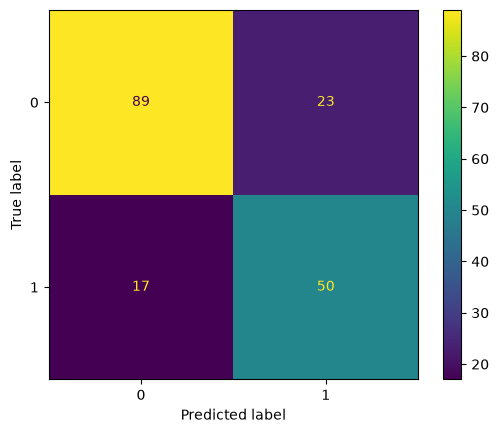

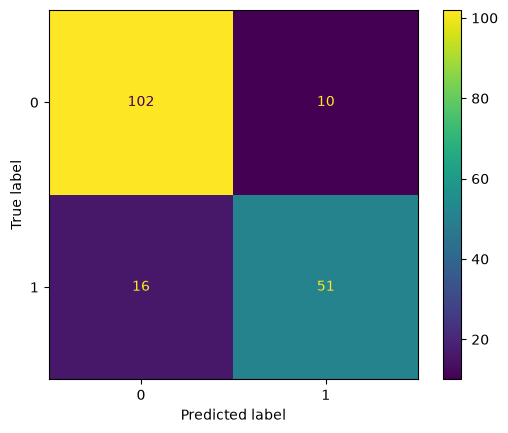

In [63]:
# confusion matrix
ConfusionMatrixDisplay.from_predictions(yval, ypred1)
ConfusionMatrixDisplay.from_predictions(yval, ypredt)
plt.show()

In [64]:
# when i limited max_leaf nodes to 500, the accuracy changed from 0.77 to 0.79, other parameters also changes as well
# i'll tweak some more until I think that I achieve the best out of the DecisionTree

In [65]:
# above 1000, no matter how much i increase, the accuracy doesn't change from 0.793296.. , so I'll now check
# what happens if I reduce max_leaf_nodes

In [66]:
# change suddenly happened when i set the max_leaf_nodes = 50
# accuracy at 50 - 0.85474
# 0-0 match has gotten upto 102 from 91 earlier and 89 in original, 1-1 match has not chnaged though, still at 51

In [67]:
# turns out, the value of accuracy is decreasing both at 40, 45(<50) and at 55(>50), so we'll probably continue at 50
# for best accuracy - m2

In [68]:
# RandomForestClassifier now

In [69]:
m2 = RandomForestClassifier(random_state = 69)

In [70]:
m2.fit(Xtr, ytr)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",69
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [71]:
ypred2 = m2.predict(Xval)

In [72]:
# evaluation of randomforest model individually
# accuracy
print("Accuracy : ", accuracy_score(yval, ypred2))

Accuracy :  0.8379888268156425


In [73]:
# classification report
print(classification_report(yval, ypred2))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       112
           1       0.80      0.76      0.78        67

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



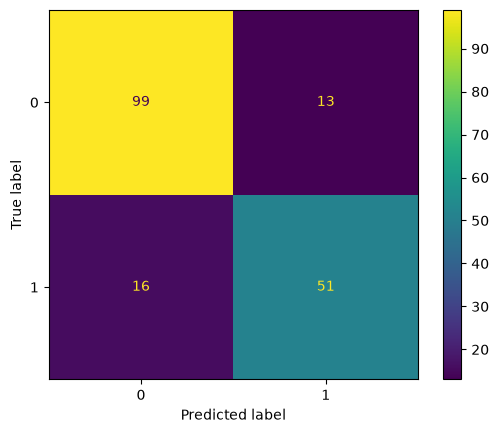

In [74]:
# confusion matrix
ConfusionMatrixDisplay.from_predictions(yval, ypred2)
plt.show()

In [75]:
# we can observe clearly that default RandomForest is not beating our tuned DecisionTree

In [76]:
# Limiting the number of leaf nodes significantly improved the Decision Tree by reducing overfitting. 
# The default Random Forest achieved similar performance but did not surpass the tuned Decision Tree on this validation split.

In [77]:
# default randomforest was at 0.8379

In [78]:
m2tuned = RandomForestClassifier(random_state = 69, max_depth = 10)
# using the max_depth parameter to tune this random forest model

In [79]:
m2tuned.fit(Xtr, ytr)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",69
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [80]:
ypred2t = m2tuned.predict(Xval)

In [81]:
print("Accuracy with max_depth = 10 : ", accuracy_score(yval, ypred2t))

Accuracy with max_depth = 10 :  0.8603351955307262


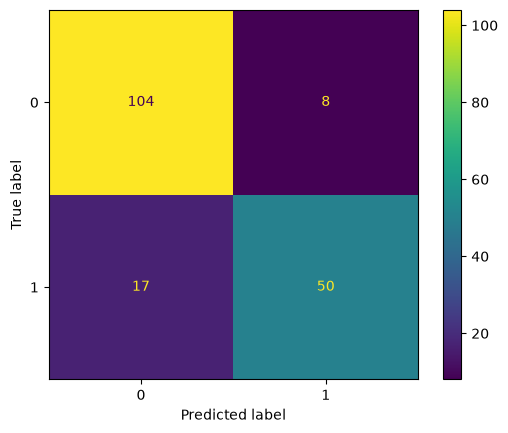

In [82]:
ConfusionMatrixDisplay.from_predictions(yval, ypred2t)
plt.show()

In [83]:
# max_depth = 10 gave us accuracy = 0.86033
# max_depth = 9 gave us accuracy = 0.84916, same at 11, just changes in classification table
# tried above 10, below 10, decreasing all the way, so max_depth = 10 is for the best accuracy for now

In [84]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": m2tuned.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance
# feature importance

,Feature,Importance
5,fareperperson,0.160985
1,Age,0.153064
2,Fare,0.135347
7,Sex_male,0.114522
10,title_Mr,0.097841
6,Sex_female,0.093199
0,Pclass,0.072926
3,famsize,0.063734
9,title_Miss,0.027532
11,title_Mrs,0.017081


In [85]:
# the feature i made - fareperperson holds the most importance

In [86]:
# generating a Kaggle submission using my best model

In [87]:
m2tuned.fit(X, y)
predictions = m2tuned.predict(test)
submission = pd.DataFrame({"PassengerId": test_ids, "Survived": predictions})
# my best model is m2tuned (RandomForestClassifier - 0.86033)

In [88]:
# exporting as a CSV file
submission.to_csv("submission.csv", index=False)

In [89]:
# this concludes this basic ML project

# Conclusion

This project was built to understand and implement the complete machine learning workflow using the Kaggle Titanic dataset.

## Key Takeaways

- Performed Exploratory Data Analysis (EDA) to understand the dataset and identify useful patterns.
- Handled missing values and cleaned the data before training.
- Engineered new features such as **FamilySize**, **IsAlone**, **FarePerPerson**, and **Title**.
- Applied one-hot encoding to categorical features.
- Trained and compared multiple machine learning models.
- Tuned hyperparameters to improve model performance and reduce overfitting.
- Generated predictions on the test dataset and created a Kaggle submission.

## Final Model Performance

| Model | Validation Accuracy |
|------|--------------------:|
| Decision Tree | ~77% |
| Tuned Decision Tree | ~85% |
| Random Forest | ~84–85% |
| **Tuned Random Forest** | **~86%** |

## Future Improvements

- Perform cross-validation for more robust evaluation.
- Explore GridSearchCV or RandomizedSearchCV for systematic hyperparameter tuning.
- Experiment with Gradient Boosting and XGBoost.
- Apply more advanced feature engineering techniques.

---

This notebook reflects my first end-to-end machine learning project and focuses on understanding the complete workflow rather than solely optimizing the Kaggle leaderboard score.